Generated 50 data points.


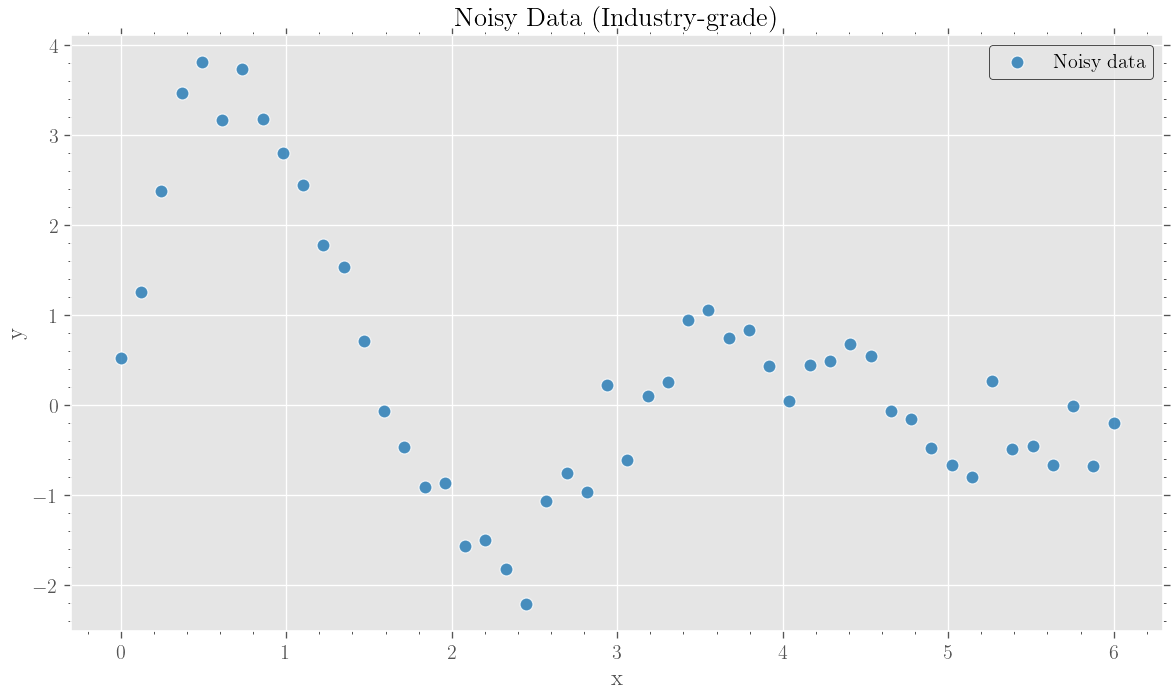

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Define the true model
def model_true(x):
    return 5 * np.exp(-0.5 * x) * np.sin(2 * x)

# Generate data points
xdata = np.linspace(0, 6, 50)
np.random.seed(0)
ydata = model_true(xdata) + 0.3 * np.random.normal(scale=1.0, size=xdata.shape)

# Pair them up as (x, y)
data = list(zip(xdata, ydata))

print(f"Generated {len(data)} data points.")
plt.style.use('ggplot')
plt.figure(figsize=(10, 6), dpi=120)
plt.scatter(xdata, ydata, label='Noisy data', color='tab:blue', s=60, edgecolor='white', linewidth=0.7, alpha=0.8)
plt.title('Noisy Data (Industry-grade)', fontsize=16, fontweight='bold')
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(frameon=True, edgecolor='black', fontsize=12)
plt.tight_layout()
plt.show()

In [2]:
from scipy.optimize import curve_fit

# 1. Define the model structure
def model(x, a, k, b):
    return a * np.exp(-k * x) * np.sin(b * x)

# 2. Perform non-linear least squares fit
initial_guess = [4.5, 0.45, 1.9]
params, cov = curve_fit(model, xdata, ydata, p0=initial_guess)
a_fit, k_fit, b_fit = params

print("Fit Parameters:")
print(f"a = {a_fit:.4f}")
print(f"k = {k_fit:.4f}")
print(f"b = {b_fit:.4f}")

# 3. Create the fitted function
def f_fitted(x):
    return model(x, a_fit, k_fit, b_fit)

Fit Parameters:
a = 5.3515
k = 0.5088
b = 1.9985


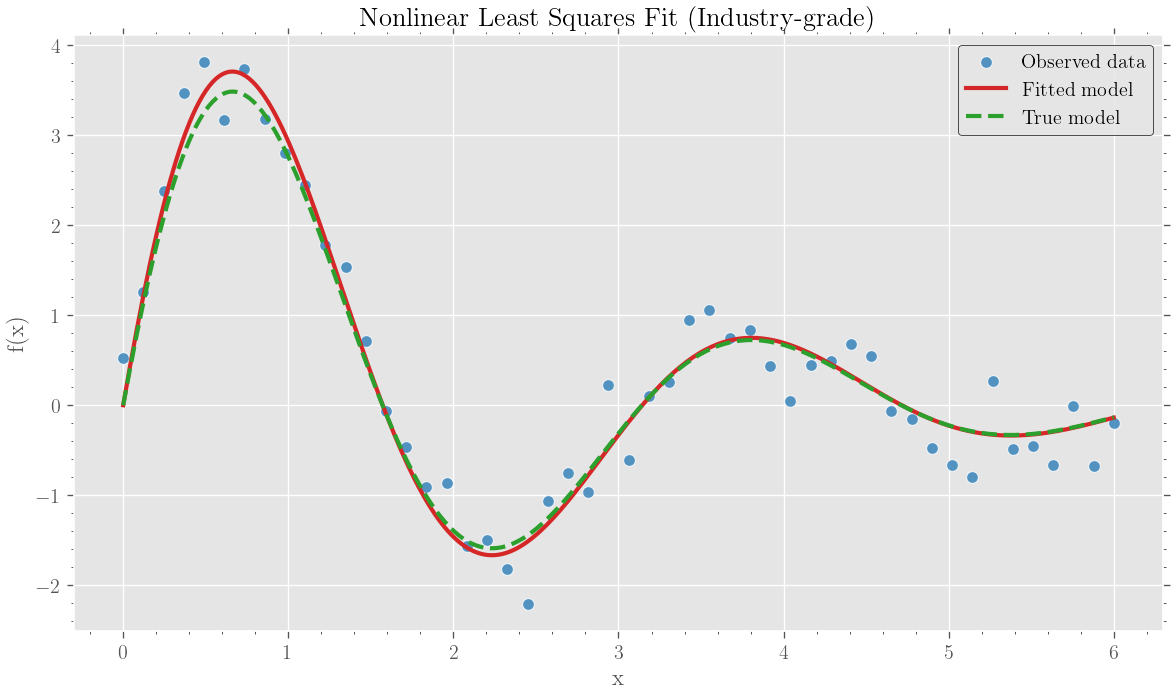

In [3]:
import matplotlib.pyplot as plt

x_plot = np.linspace(0, 6, 300)

plt.style.use('ggplot')
plt.figure(figsize=(10, 6), dpi=120)
plt.scatter(xdata, ydata, label='Observed data', color='tab:blue', s=50, edgecolor='white', linewidth=0.7, alpha=0.75)
plt.plot(x_plot, f_fitted(x_plot), color='tab:red', linewidth=2.5, label='Fitted model')
plt.plot(x_plot, model_true(x_plot), color='tab:green', linestyle='--', linewidth=2.5, label='True model')

plt.title('Nonlinear Least Squares Fit (Industry-grade)', fontsize=16, fontweight='bold')
plt.xlabel('x', fontsize=14)
plt.ylabel('f(x)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(frameon=True, edgecolor='black', fontsize=12)
plt.tight_layout()
plt.show()